In [55]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

df = pd.read_csv('resultados copy.csv', sep=',')
df=df[1:]

grafos = df['Grafo'].unique().tolist()
algoritmos = df['Algoritmo'].unique().tolist()
vetor_df = []
for g in grafos:
    for a in algoritmos:
        dfTemp = df.loc[df['Grafo'] == g].loc[df['Algoritmo'] == a]
        vetor_df.append([g, a, dfTemp])

display(len(vetor_df))





12

## Comparativo todos cenarios   

In [56]:
dfGeral = pd.DataFrame(columns=['Grafo', 'Algoritmo', 'Fit Inicial Médio', 'Fit Melhor Médio', 'Tempo Execução Médio (s)', 'Ganho Relativo Médio (%)'])



for df in vetor_df:
    tempo_execucao = []
    ganho_relativo = []
    grafo = df[0]
    algoritmo = df[1][3:]
    texto = (grafo + algoritmo).replace(" ", "_").replace("-", "_")
    dataframe = df[2]
    fit_inicial_medio = np.mean(dataframe['Fit Inicial'].astype(float))
    fit_melhor_medio = np.mean(dataframe['Fit Final'].astype(float))
    tempo = np.mean(dataframe['Tempo Execução (s)'].astype(float))
    tempo_execucao.append(tempo)
    tempo_execucao_medio = tempo
    ganho = np.mean(dataframe['Ganho Relativo (%)'].astype(float))
    ganho_relativo.append(ganho)
    ganho_relativo_medio = ganho

    dfGeral = pd.concat([dfGeral, pd.DataFrame([[grafo, algoritmo, fit_inicial_medio, fit_melhor_medio, tempo_execucao_medio, ganho_relativo_medio]], columns=dfGeral.columns)], ignore_index=True)
    

dfGeral = dfGeral.sort_values(by=['Grafo', 'Algoritmo'], ascending=[True, False])
dfGeral.to_csv('tabelas/resultados_geral.csv', index=False)
dfGeral.to_latex('tabelas/resultados_geral.tex', index=False, float_format="%.2f")

display(dfGeral)


/tmp/ipykernel_167225/2024354338.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  dfGeral = pd.concat([dfGeral, pd.DataFrame([[grafo, algoritmo, fit_inicial_medio, fit_melhor_medio, tempo_execucao_medio, ganho_relativo_medio]], columns=dfGeral.columns)], ignore_index=True)


,Grafo,Algoritmo,Fit Inicial Médio,Fit Melhor Médio,Tempo Execução Médio (s),Ganho Relativo Médio (%)
3,berlin52,Original,25838.602220,13591.792947,0.888048,47.377946
0,berlin52,1DeleteCross,25780.455420,9703.836042,3.732751,62.336882
1,berlin52,1DC-Solucao-Cluster2x2,25705.110306,11778.955724,3.156694,54.125008
2,berlin52,1DC-AG-Cluster2x2,25713.748104,9565.703209,5.670835,62.766655
7,ch150,Original,49130.654725,29406.782409,4.270797,40.136434
4,ch150,1DeleteCross,49379.838827,19328.587330,12.825439,60.822892
5,ch150,1DC-Solucao-Cluster2x2,49467.473653,9760.481800,12.762500,80.262828
6,ch150,1DC-AG-Cluster2x2,49262.676435,9659.680736,32.885516,80.382996
11,rd400,Original,200463.823784,126386.854789,24.766673,36.950178
8,rd400,1DeleteCross,200291.605068,81623.422612,54.823543,59.247296


# Comparativo por Cluster

<>:23: SyntaxWarning: invalid escape sequence '\s'
<>:23: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_167225/1369077596.py:23: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(x, valores_tempo, marker="o", label=f"{algoritmo} ($\sigma={dp:.2f}$)")


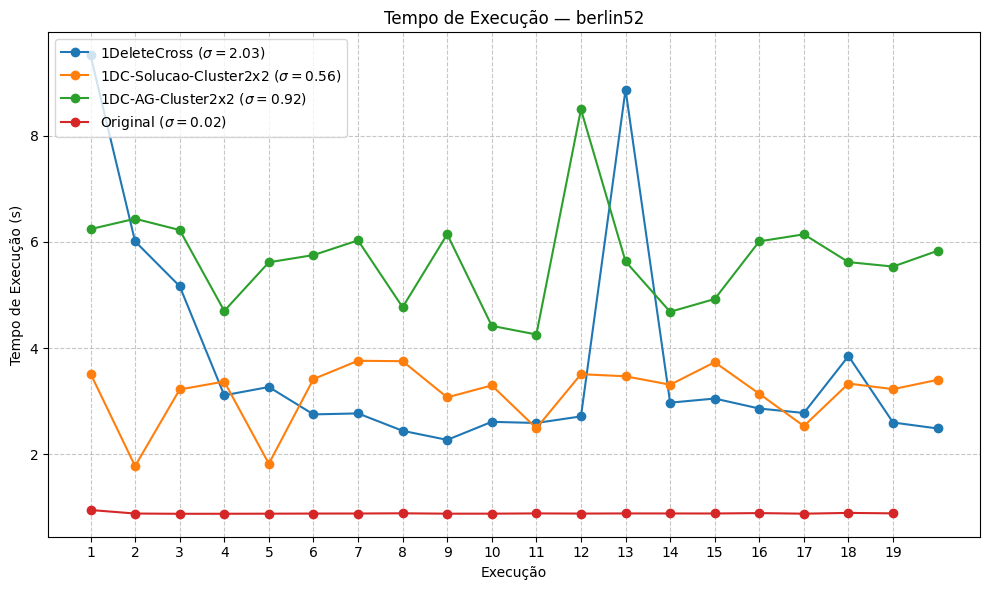

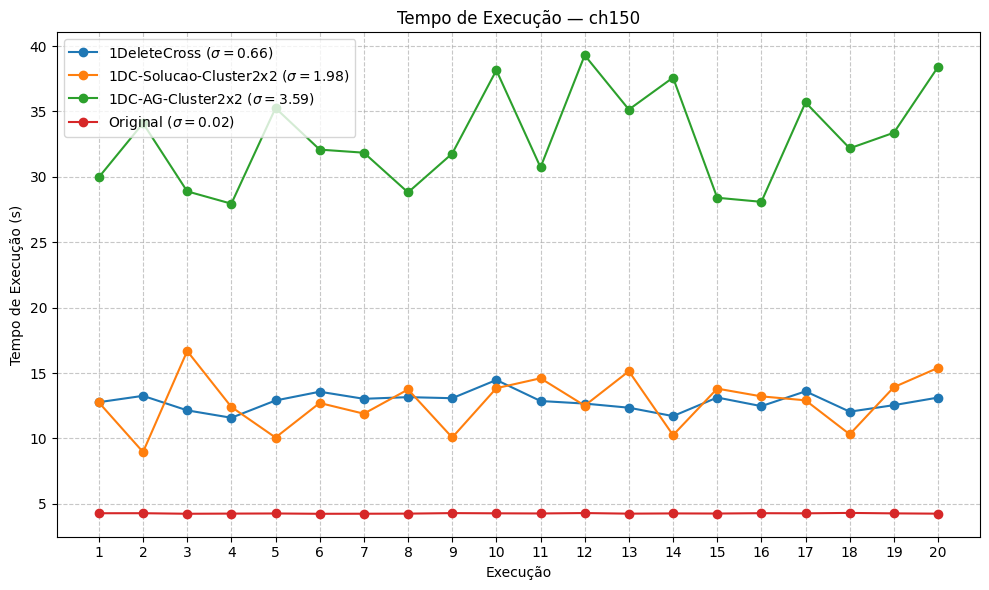

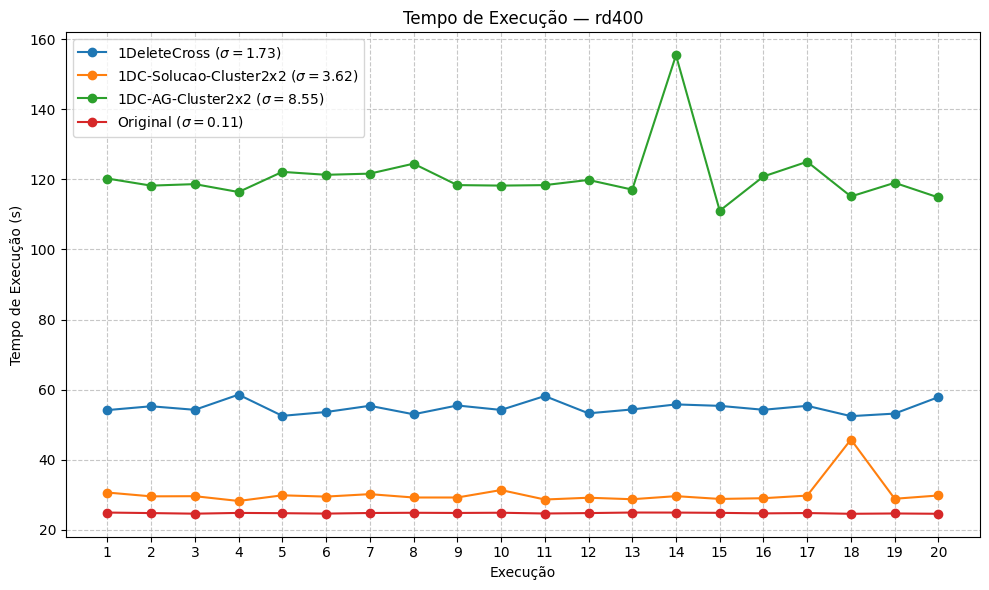

In [57]:
import matplotlib.pyplot as plt
import numpy as np

title = True
extensao = ".png"

plt.style.use('fast')

for g in grafos:
    vetor = [item for item in vetor_df if item[0] == g]

    plt.figure(figsize=(10, 6))

    for item in vetor:
        algoritmo = item[1][3:].replace(" ", "_")
        dftemp = item[2]
        valores_tempo = dftemp['Tempo Execução (s)'].astype(float).tolist()

        n = len(valores_tempo)
        x = list(range(1, n + 1))

        dp = np.std(valores_tempo)
        plt.plot(x, valores_tempo, marker="o", label=f"{algoritmo} ($\sigma={dp:.2f}$)")

    plt.xticks(ticks=list(range(1, n + 1)), labels=list(range(1, n + 1)))
    plt.xlabel("Execução")
    plt.ylabel("Tempo de Execução (s)")

    if title:
        plt.title(f"Tempo de Execução — {g}")

    plt.legend(loc="upper left")
    plt.tight_layout()
    plt.grid(True, linestyle='--', alpha=0.7)

    nome_arquivo = f"graficos/tempos_execucao_{g}{extensao}"
    plt.savefig(nome_arquivo, dpi=150)
    #plt.show()


<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_167225/2129063788.py:22: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(x, valores_ganho, marker="o", label=f"{algoritmo} ($\sigma={dp:.2f}$)")


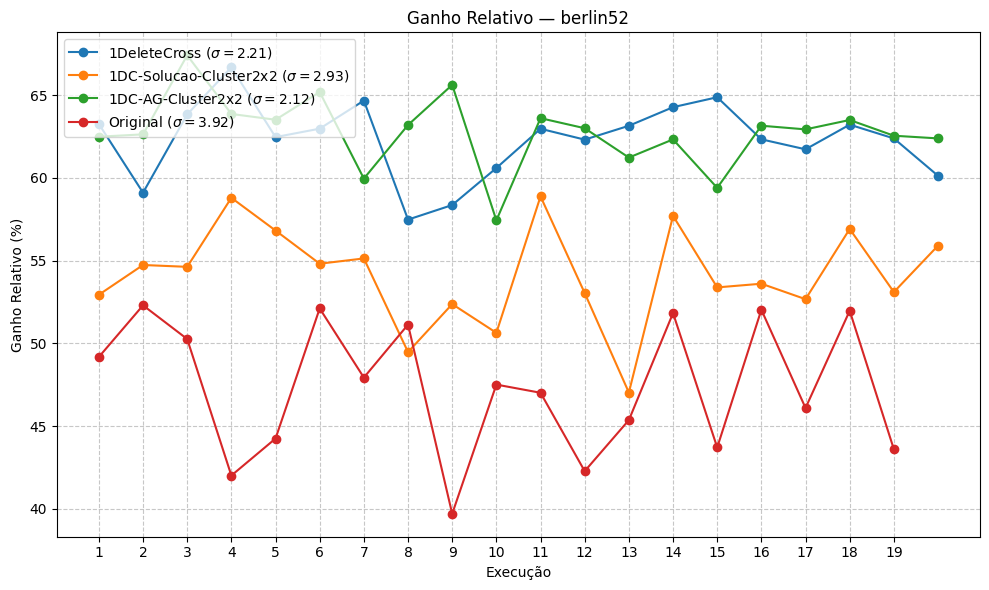

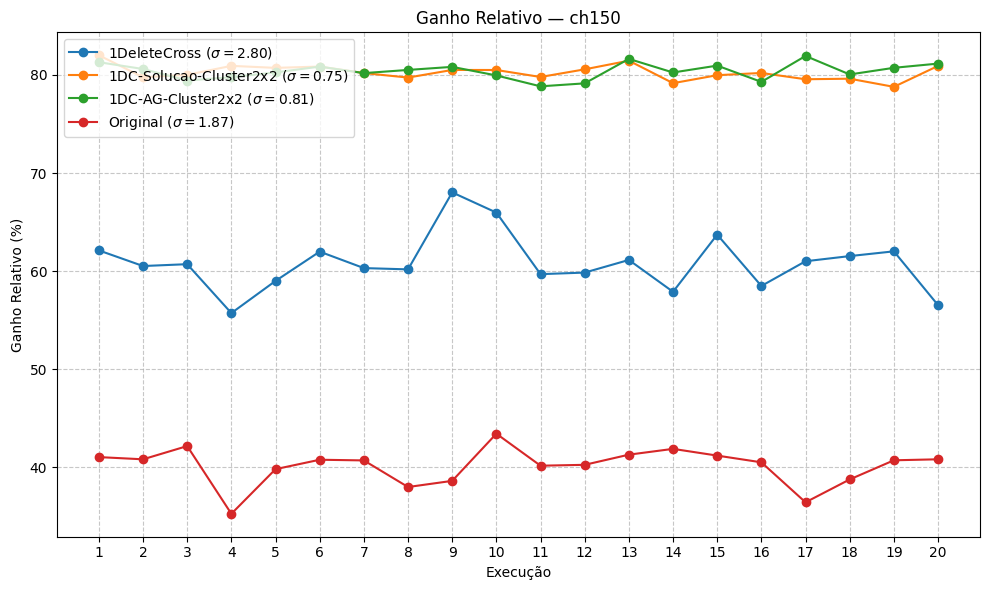

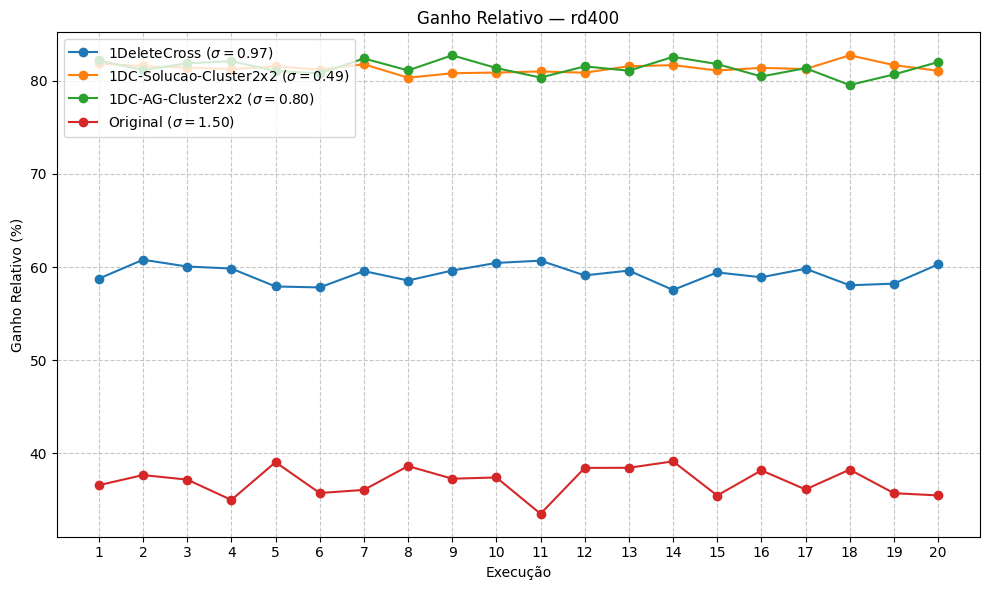

In [58]:
import numpy as np
import matplotlib.pyplot as plt

title = True
extensao = ".png"

plt.style.use('fast')

for g in grafos:
    vetor = [item for item in vetor_df if item[0] == g]

    plt.figure(figsize=(10, 6))
    for item in vetor:
        algoritmo = item[1][3:].replace(" ", "_")
        dftemp = item[2]
        valores_ganho = dftemp['Ganho Relativo (%)'].astype(float).tolist()

        n = len(valores_ganho)
        x = list(range(1, n + 1))

        dp = np.std(valores_ganho)
        plt.plot(x, valores_ganho, marker="o", label=f"{algoritmo} ($\sigma={dp:.2f}$)")

    plt.xticks(ticks=list(range(1, n + 1)), labels=list(range(1, n + 1)))
    plt.xlabel("Execução")
    plt.ylabel("Ganho Relativo (%)")

    if title:
        plt.title(f"Ganho Relativo — {g}")

    plt.legend(loc="upper left")
    plt.tight_layout()
    plt.grid(True, linestyle='--', alpha=0.7)

    nome_arquivo = f"graficos/ganho_relativo{g}{extensao}"
    plt.savefig(nome_arquivo, dpi=150)
    plt.show()
